In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
df = pd.read_csv('careers.csv')
counts = df["Interested Domain"].value_counts()

valid_domains = counts[counts >= 10].index

df = df[
    df["Interested Domain"].isin(valid_domains)
]

numeric_df = df.select_dtypes(include=['int64', 'float64'])

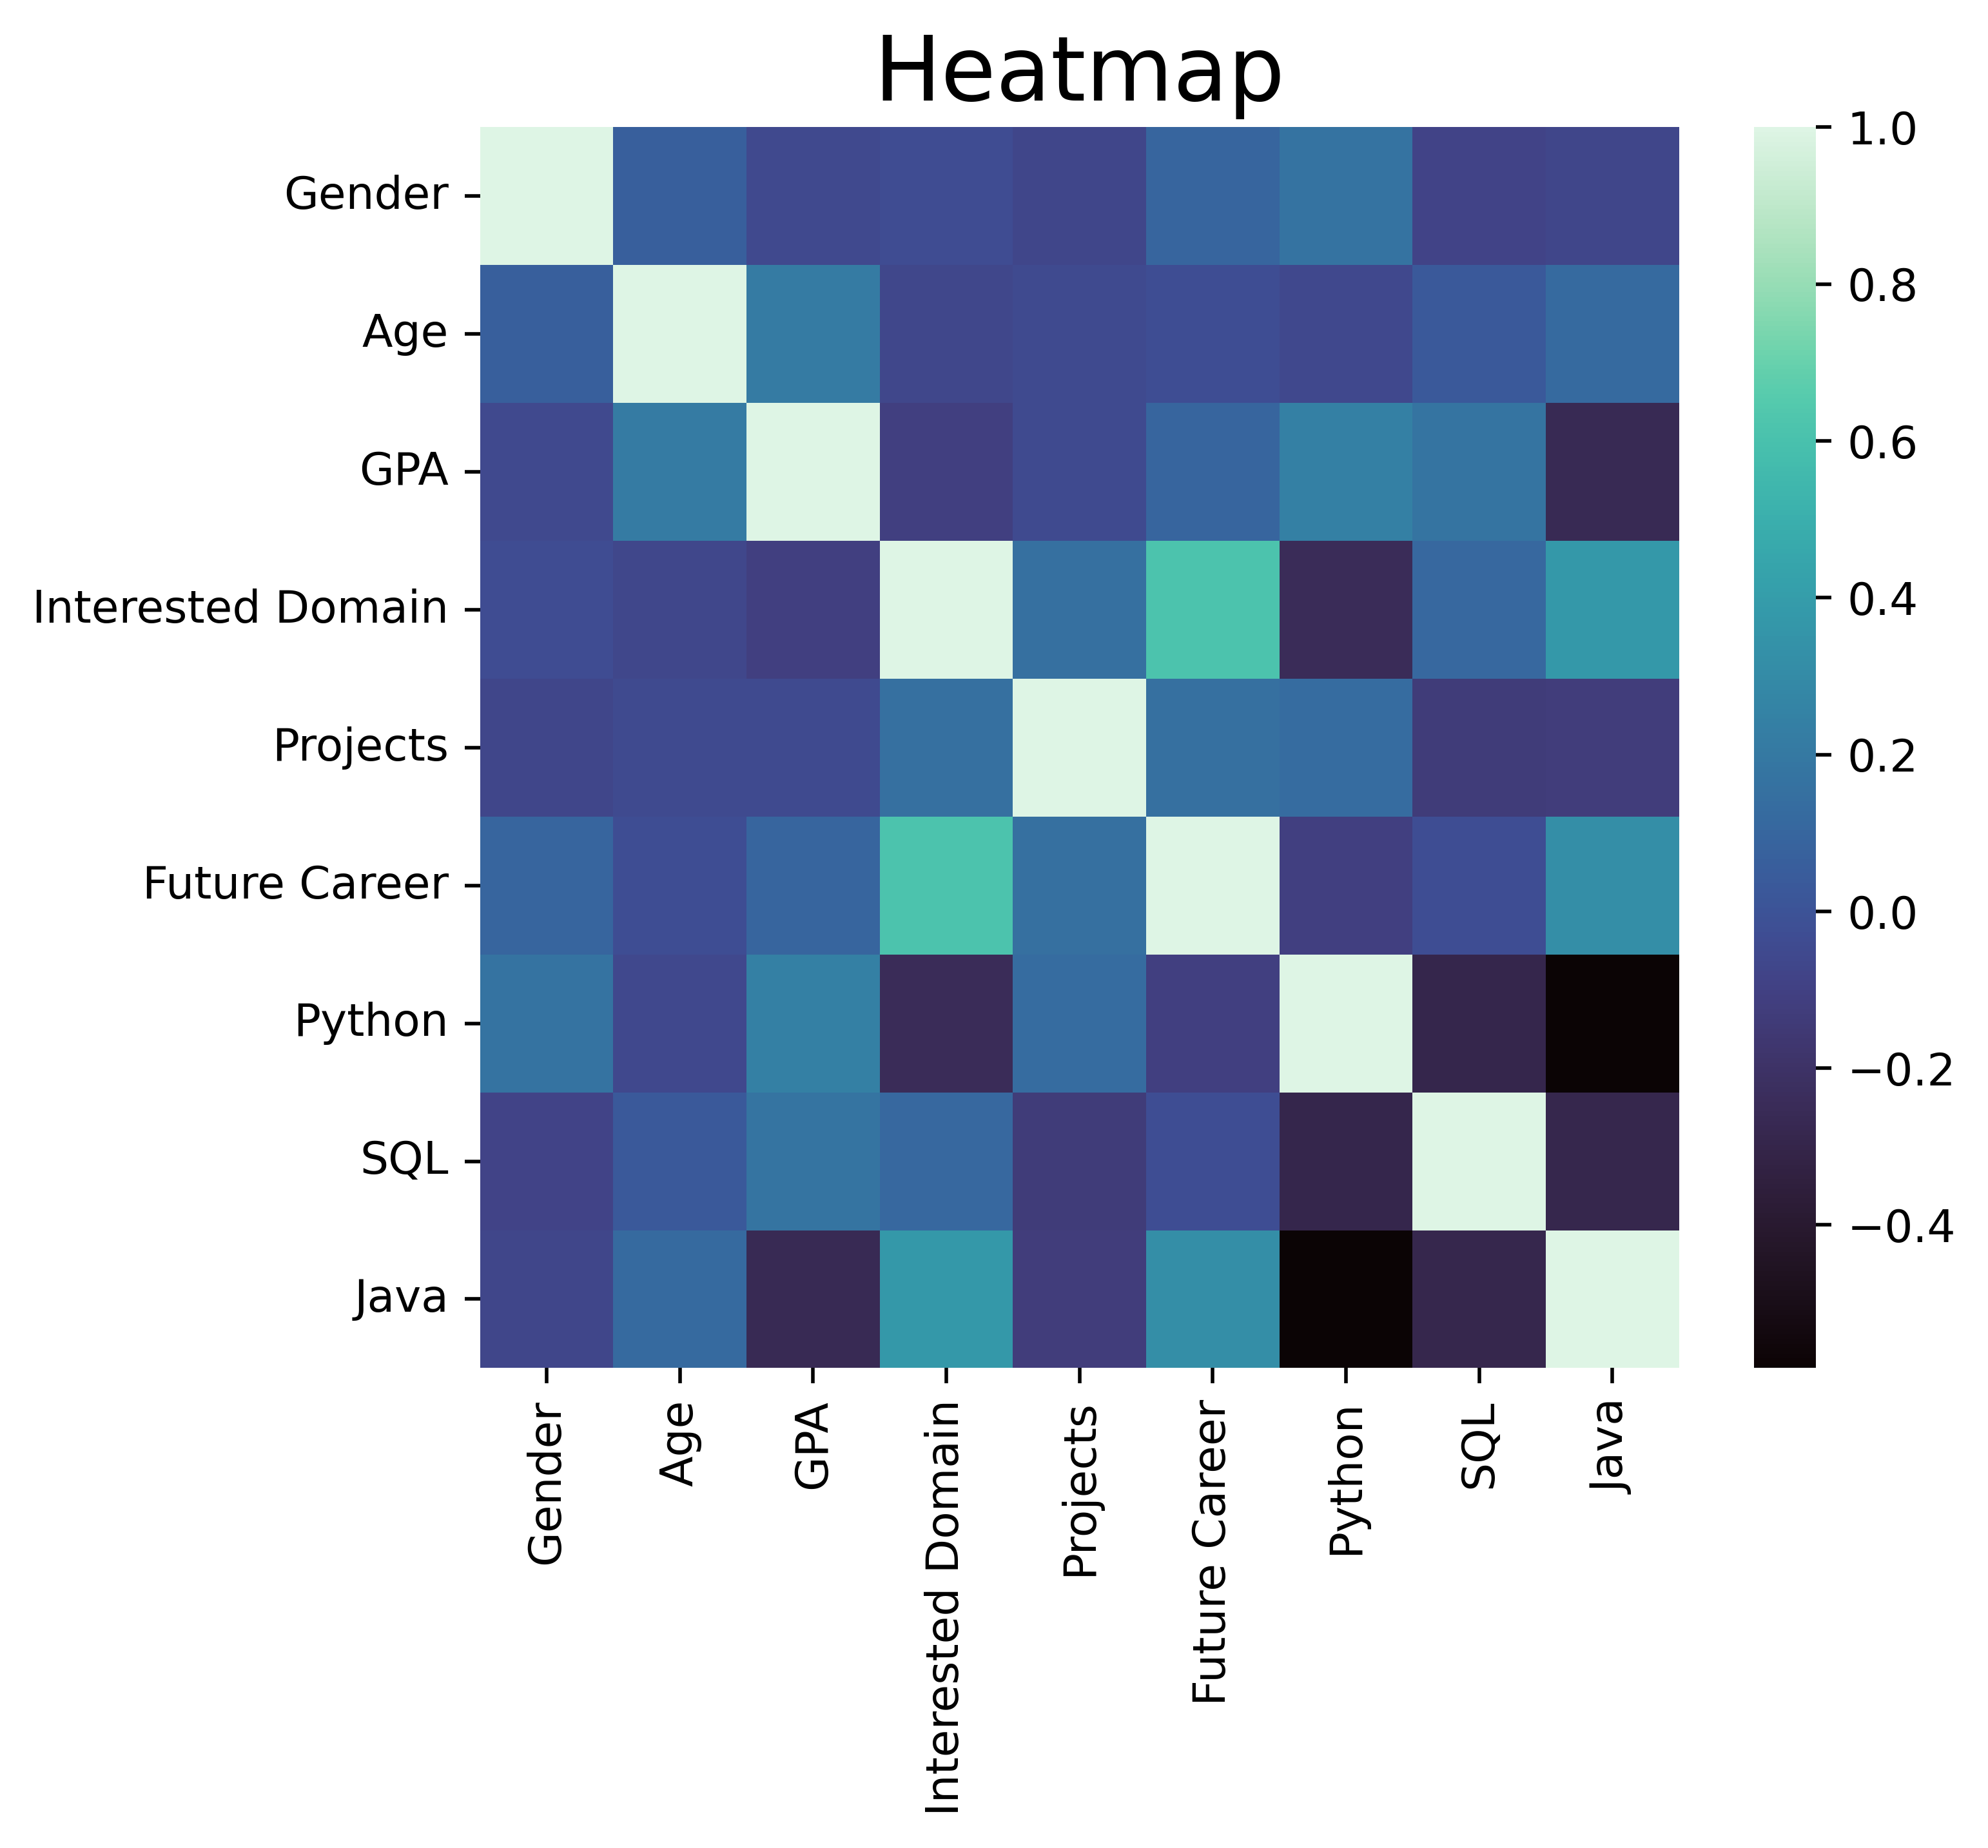

<Figure size 640x480 with 0 Axes>

In [113]:
# Heat Map 

df_encoded = df.copy()

le = LabelEncoder()

for col in ["Gender", "Major", "Interested Domain", "Projects", "Future Career"]:
    df_encoded[col] = le.fit_transform(df_encoded[col])


skill_map = {"Weak": 0, "Average": 1, "Strong": 2}
for col in ["Python", "SQL", "Java"]:
    df_encoded[col] = df_encoded[col].map(skill_map)
df_encoded = df_encoded.drop(columns=["Major"])

plt.figure(figsize=(6, 5), dpi=500)
sns.heatmap(df_encoded.corr(), cmap="mako")
plt.title("Heatmap", fontdict={'fontsize': 20})
plt.show()
plt.savefig("images/heatmap.png")

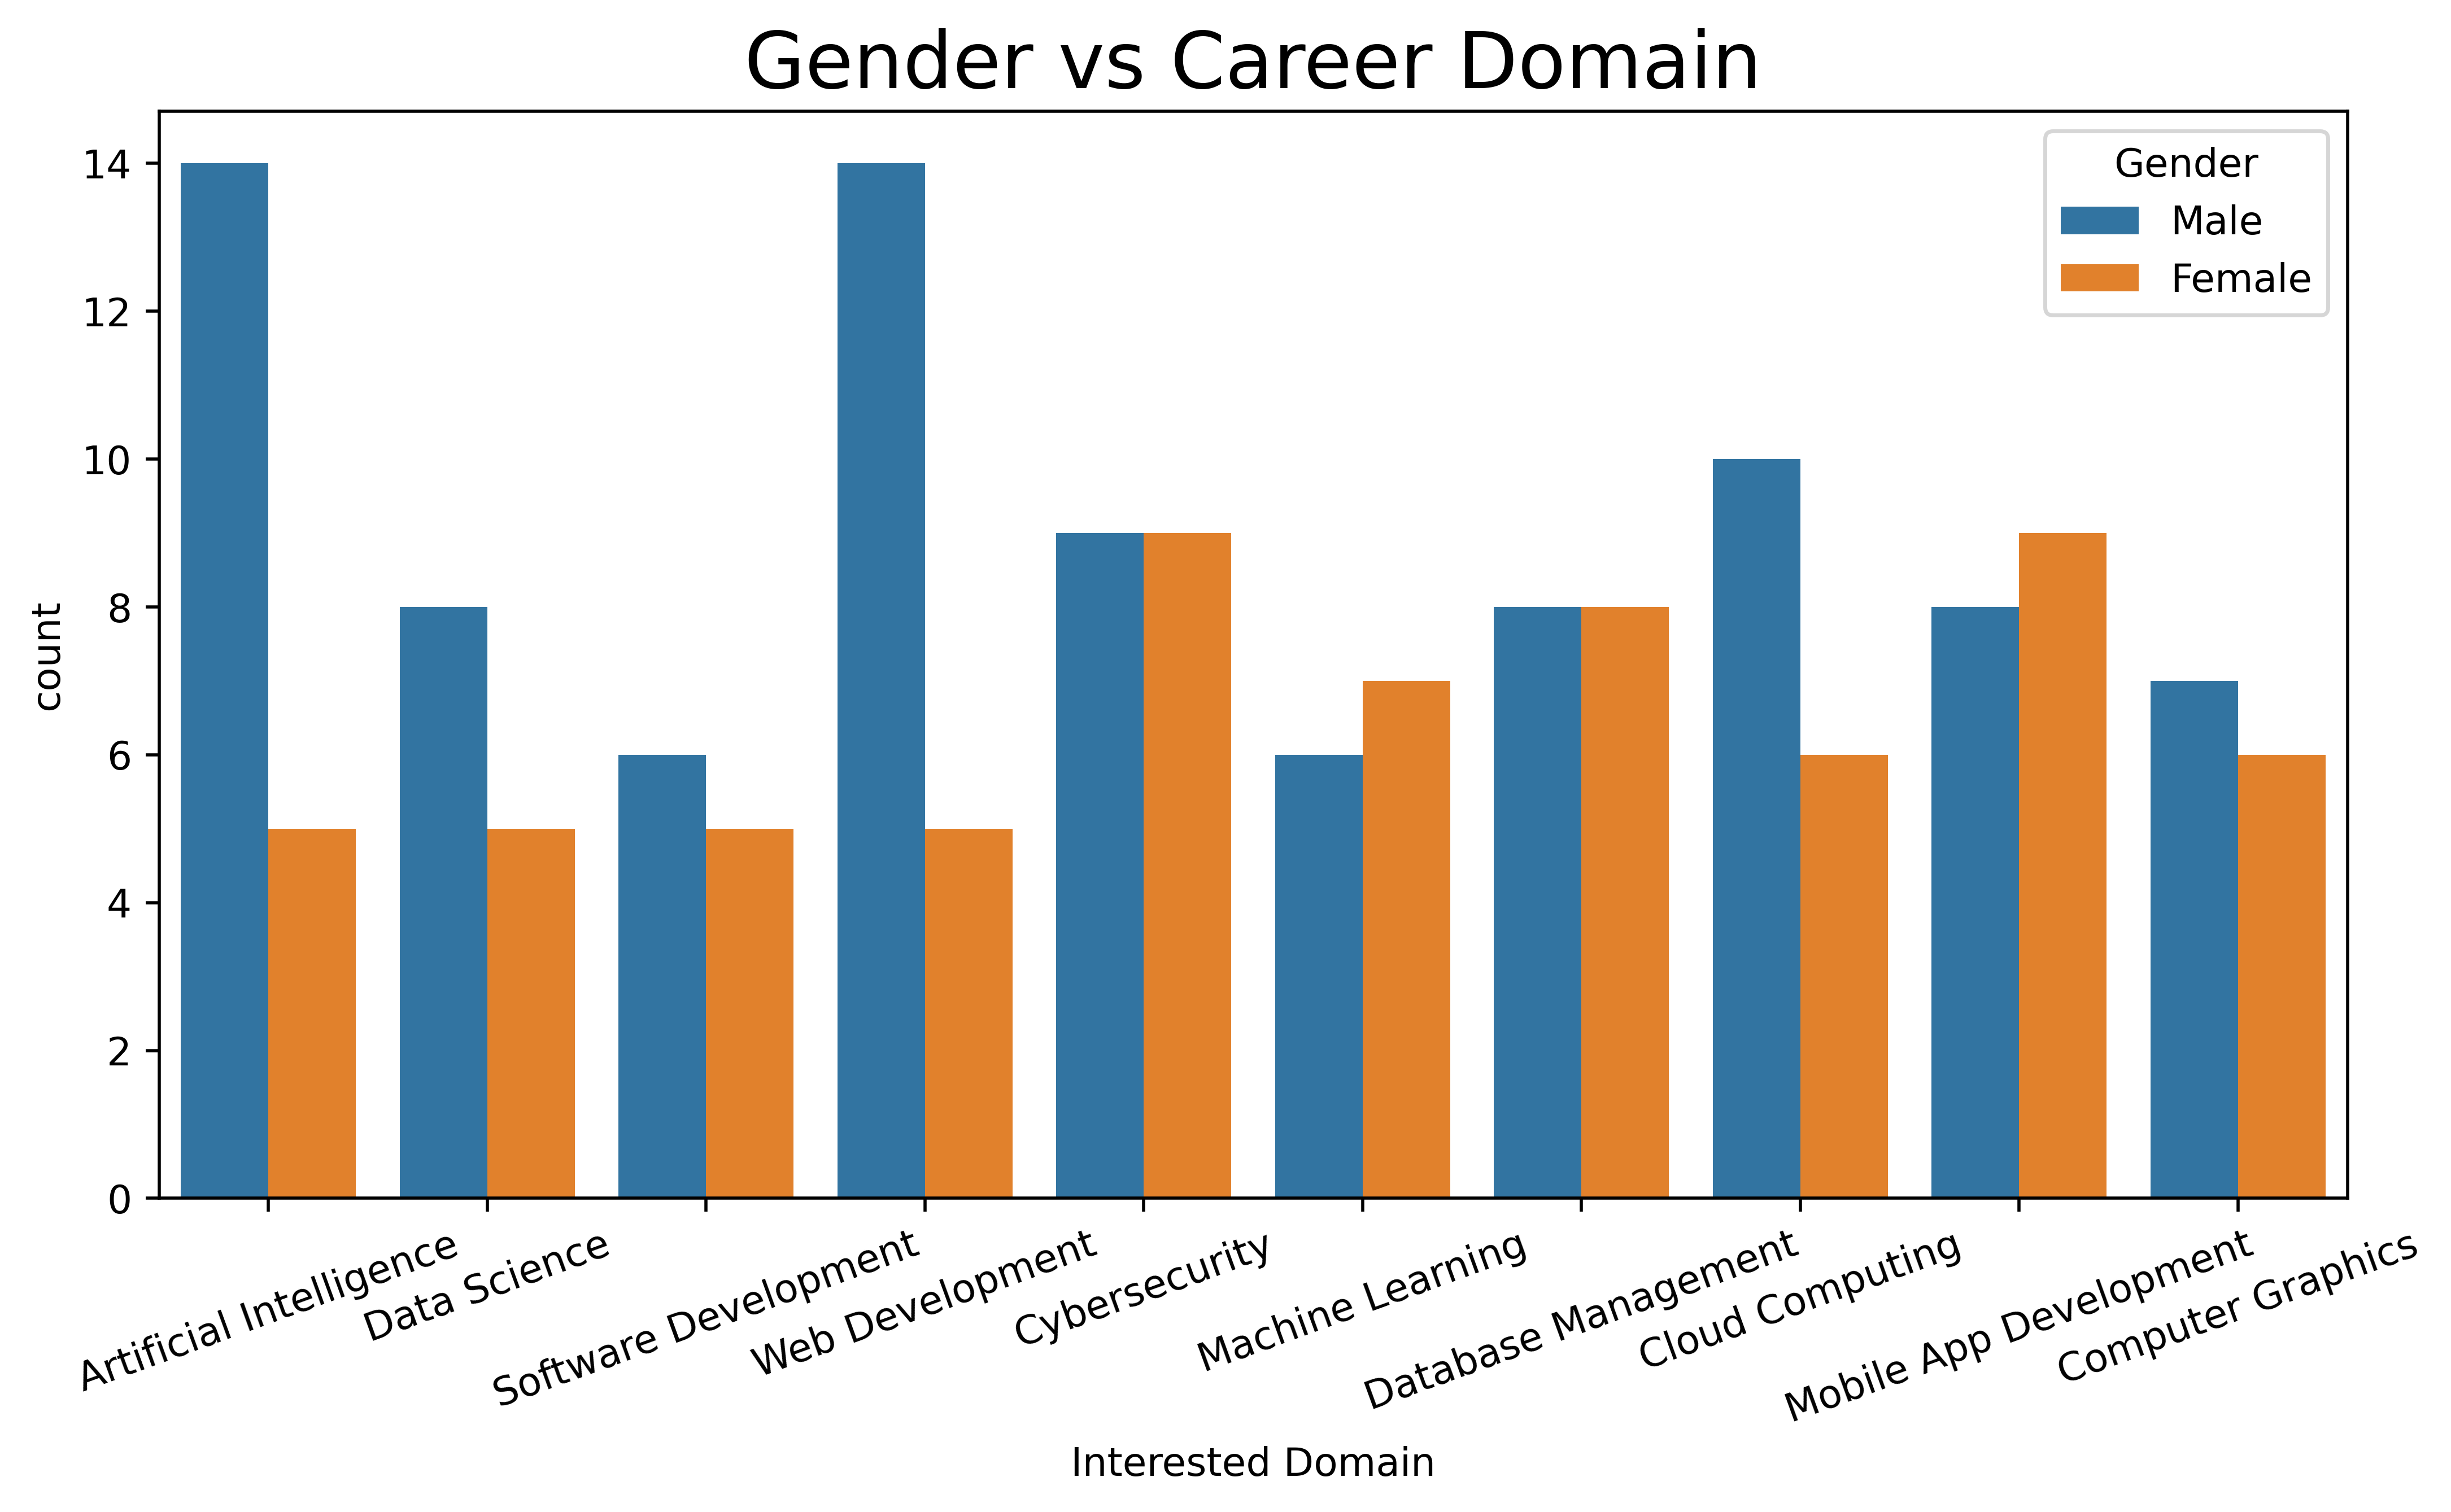

<Figure size 640x480 with 0 Axes>

In [114]:
# Gender vs Career Domain
newdf = df[['Gender', "Interested Domain"]].copy()

plt.figure(figsize=(10,5), dpi=500)
plt.title("Gender vs Career Domain", fontdict={'fontsize': 20})
sns.countplot(data=df, x="Interested Domain", hue="Gender")
plt.xticks(rotation=20)
plt.show()
plt.savefig("images/gender-domain.png")

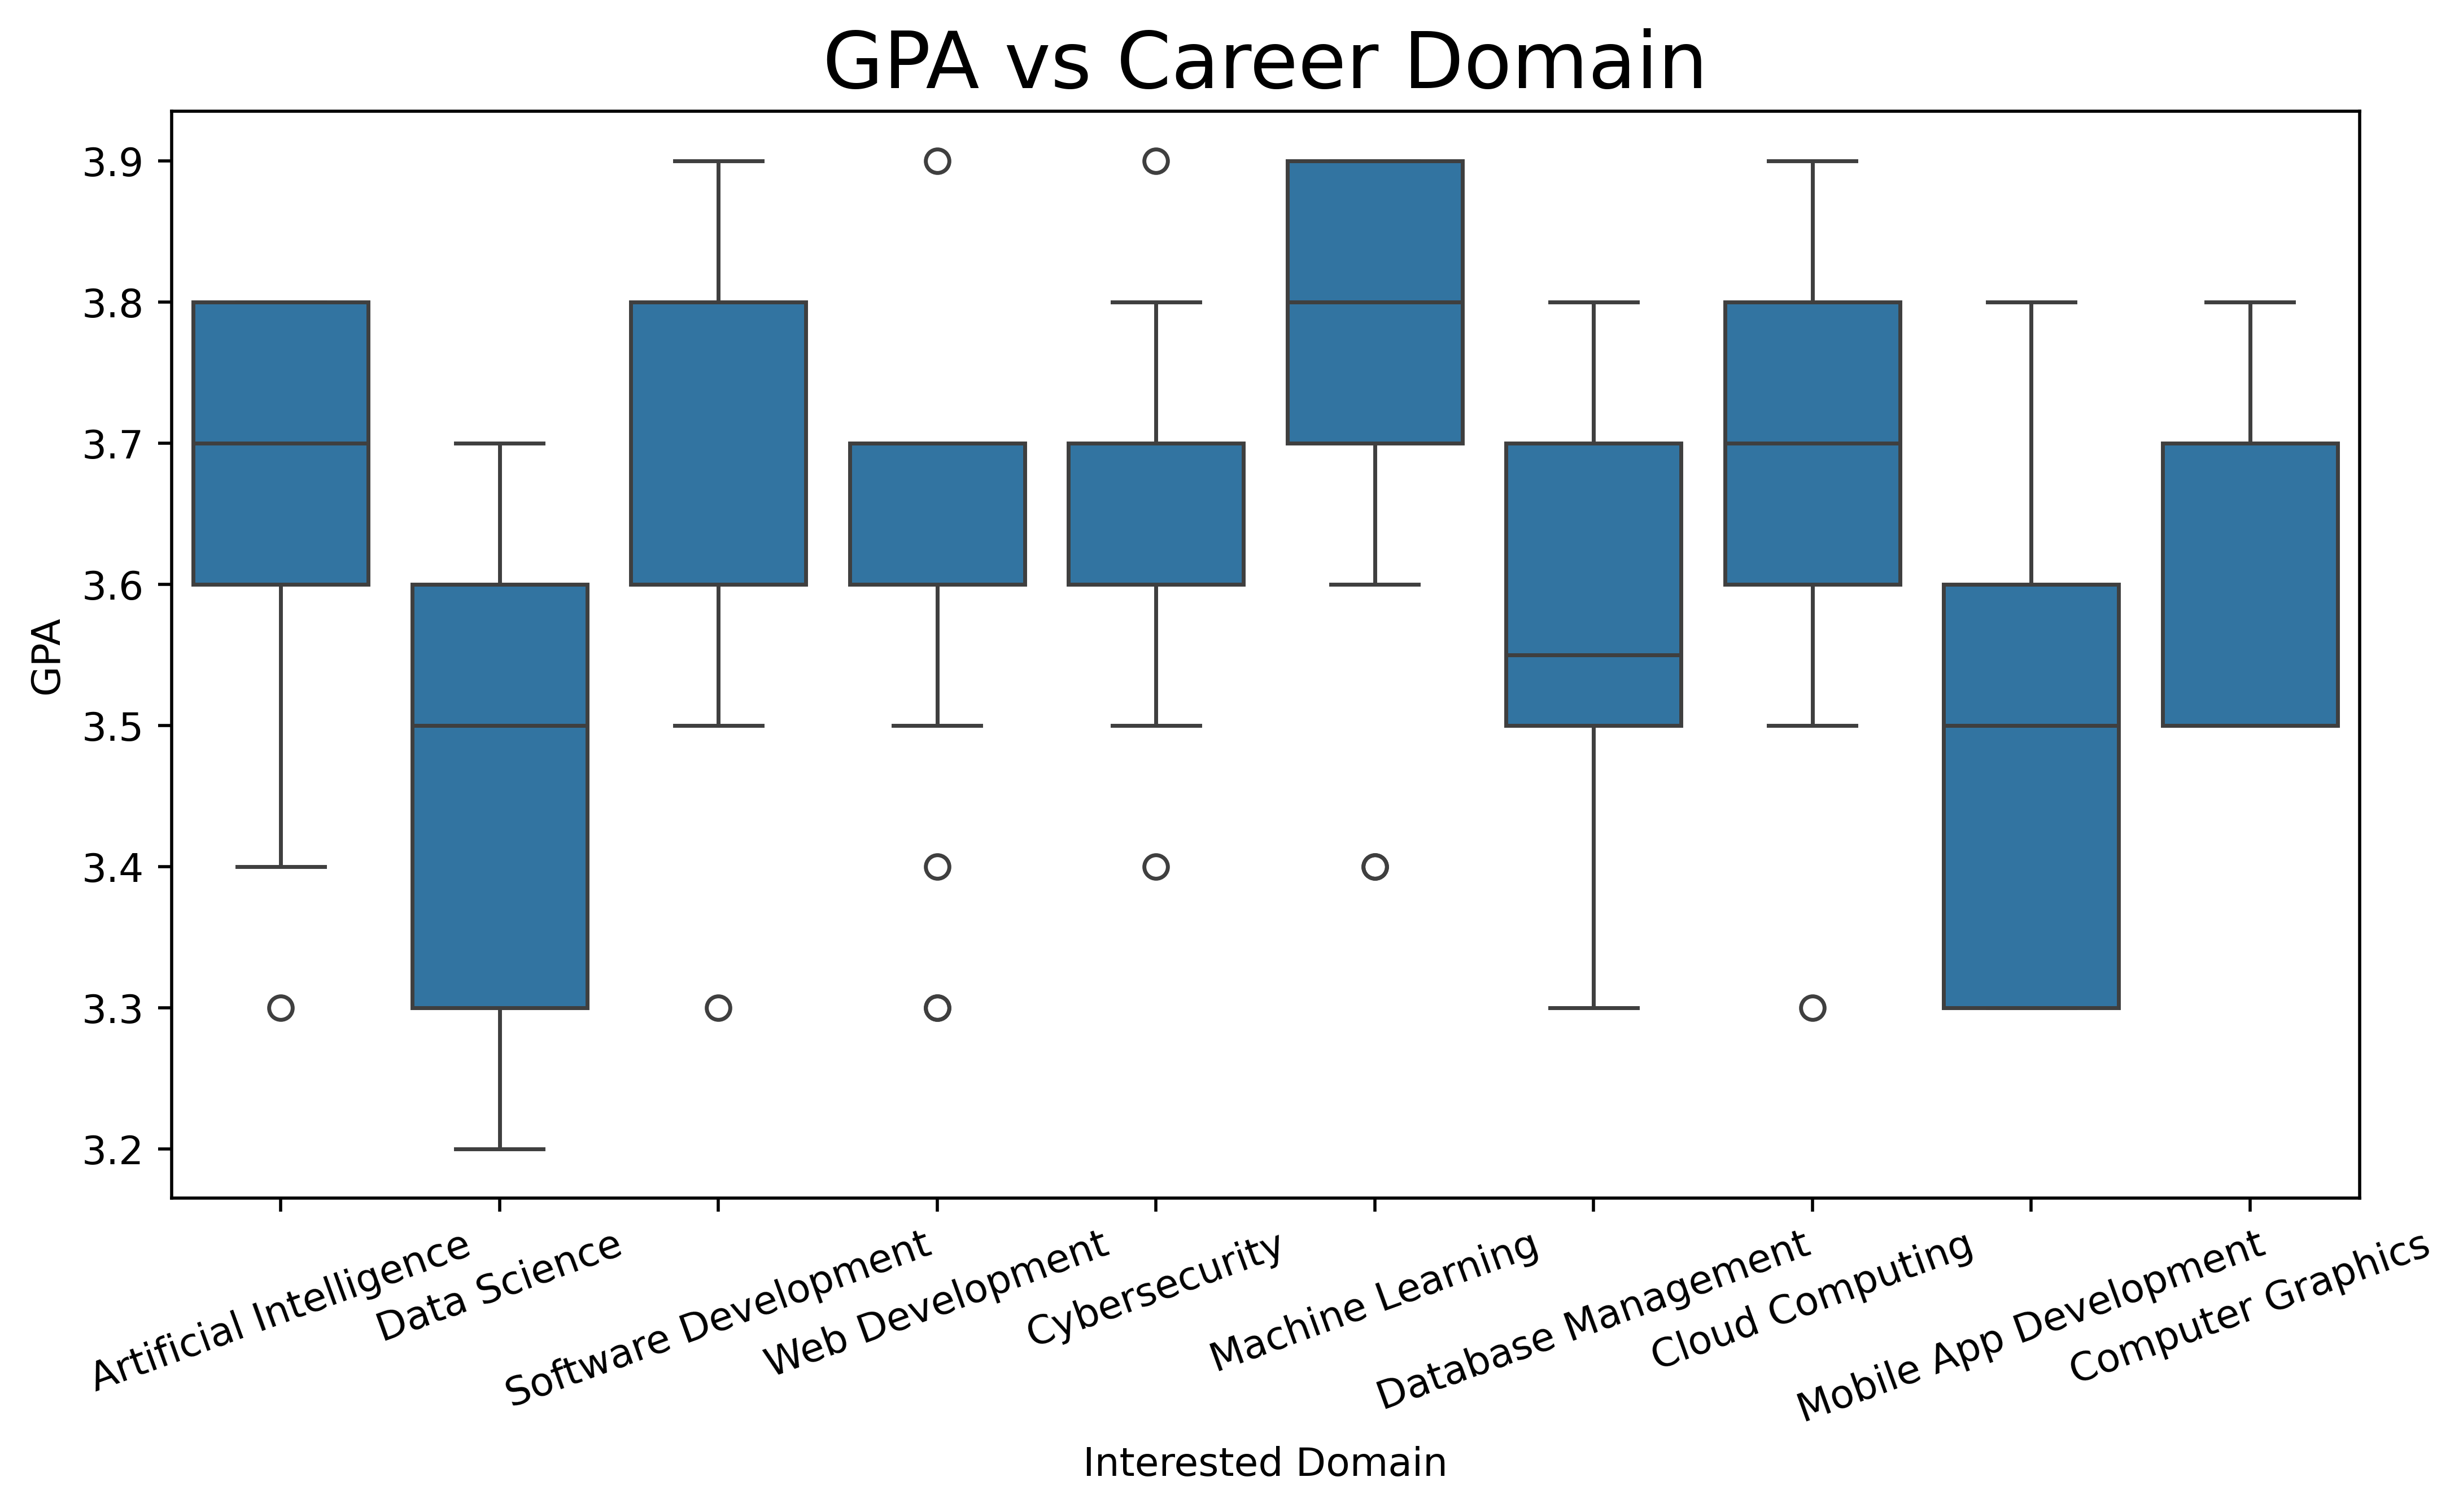

<Figure size 640x480 with 0 Axes>

In [115]:
# GPA vs Domain

plt.figure(figsize=(10,5), dpi=500)
plt.title("GPA vs Career Domain", fontdict={'fontsize': 20})
sns.boxplot(data=df, x="Interested Domain", y="GPA")
plt.xticks(rotation=20)
plt.show()
plt.savefig("images/gpa-domain.png")

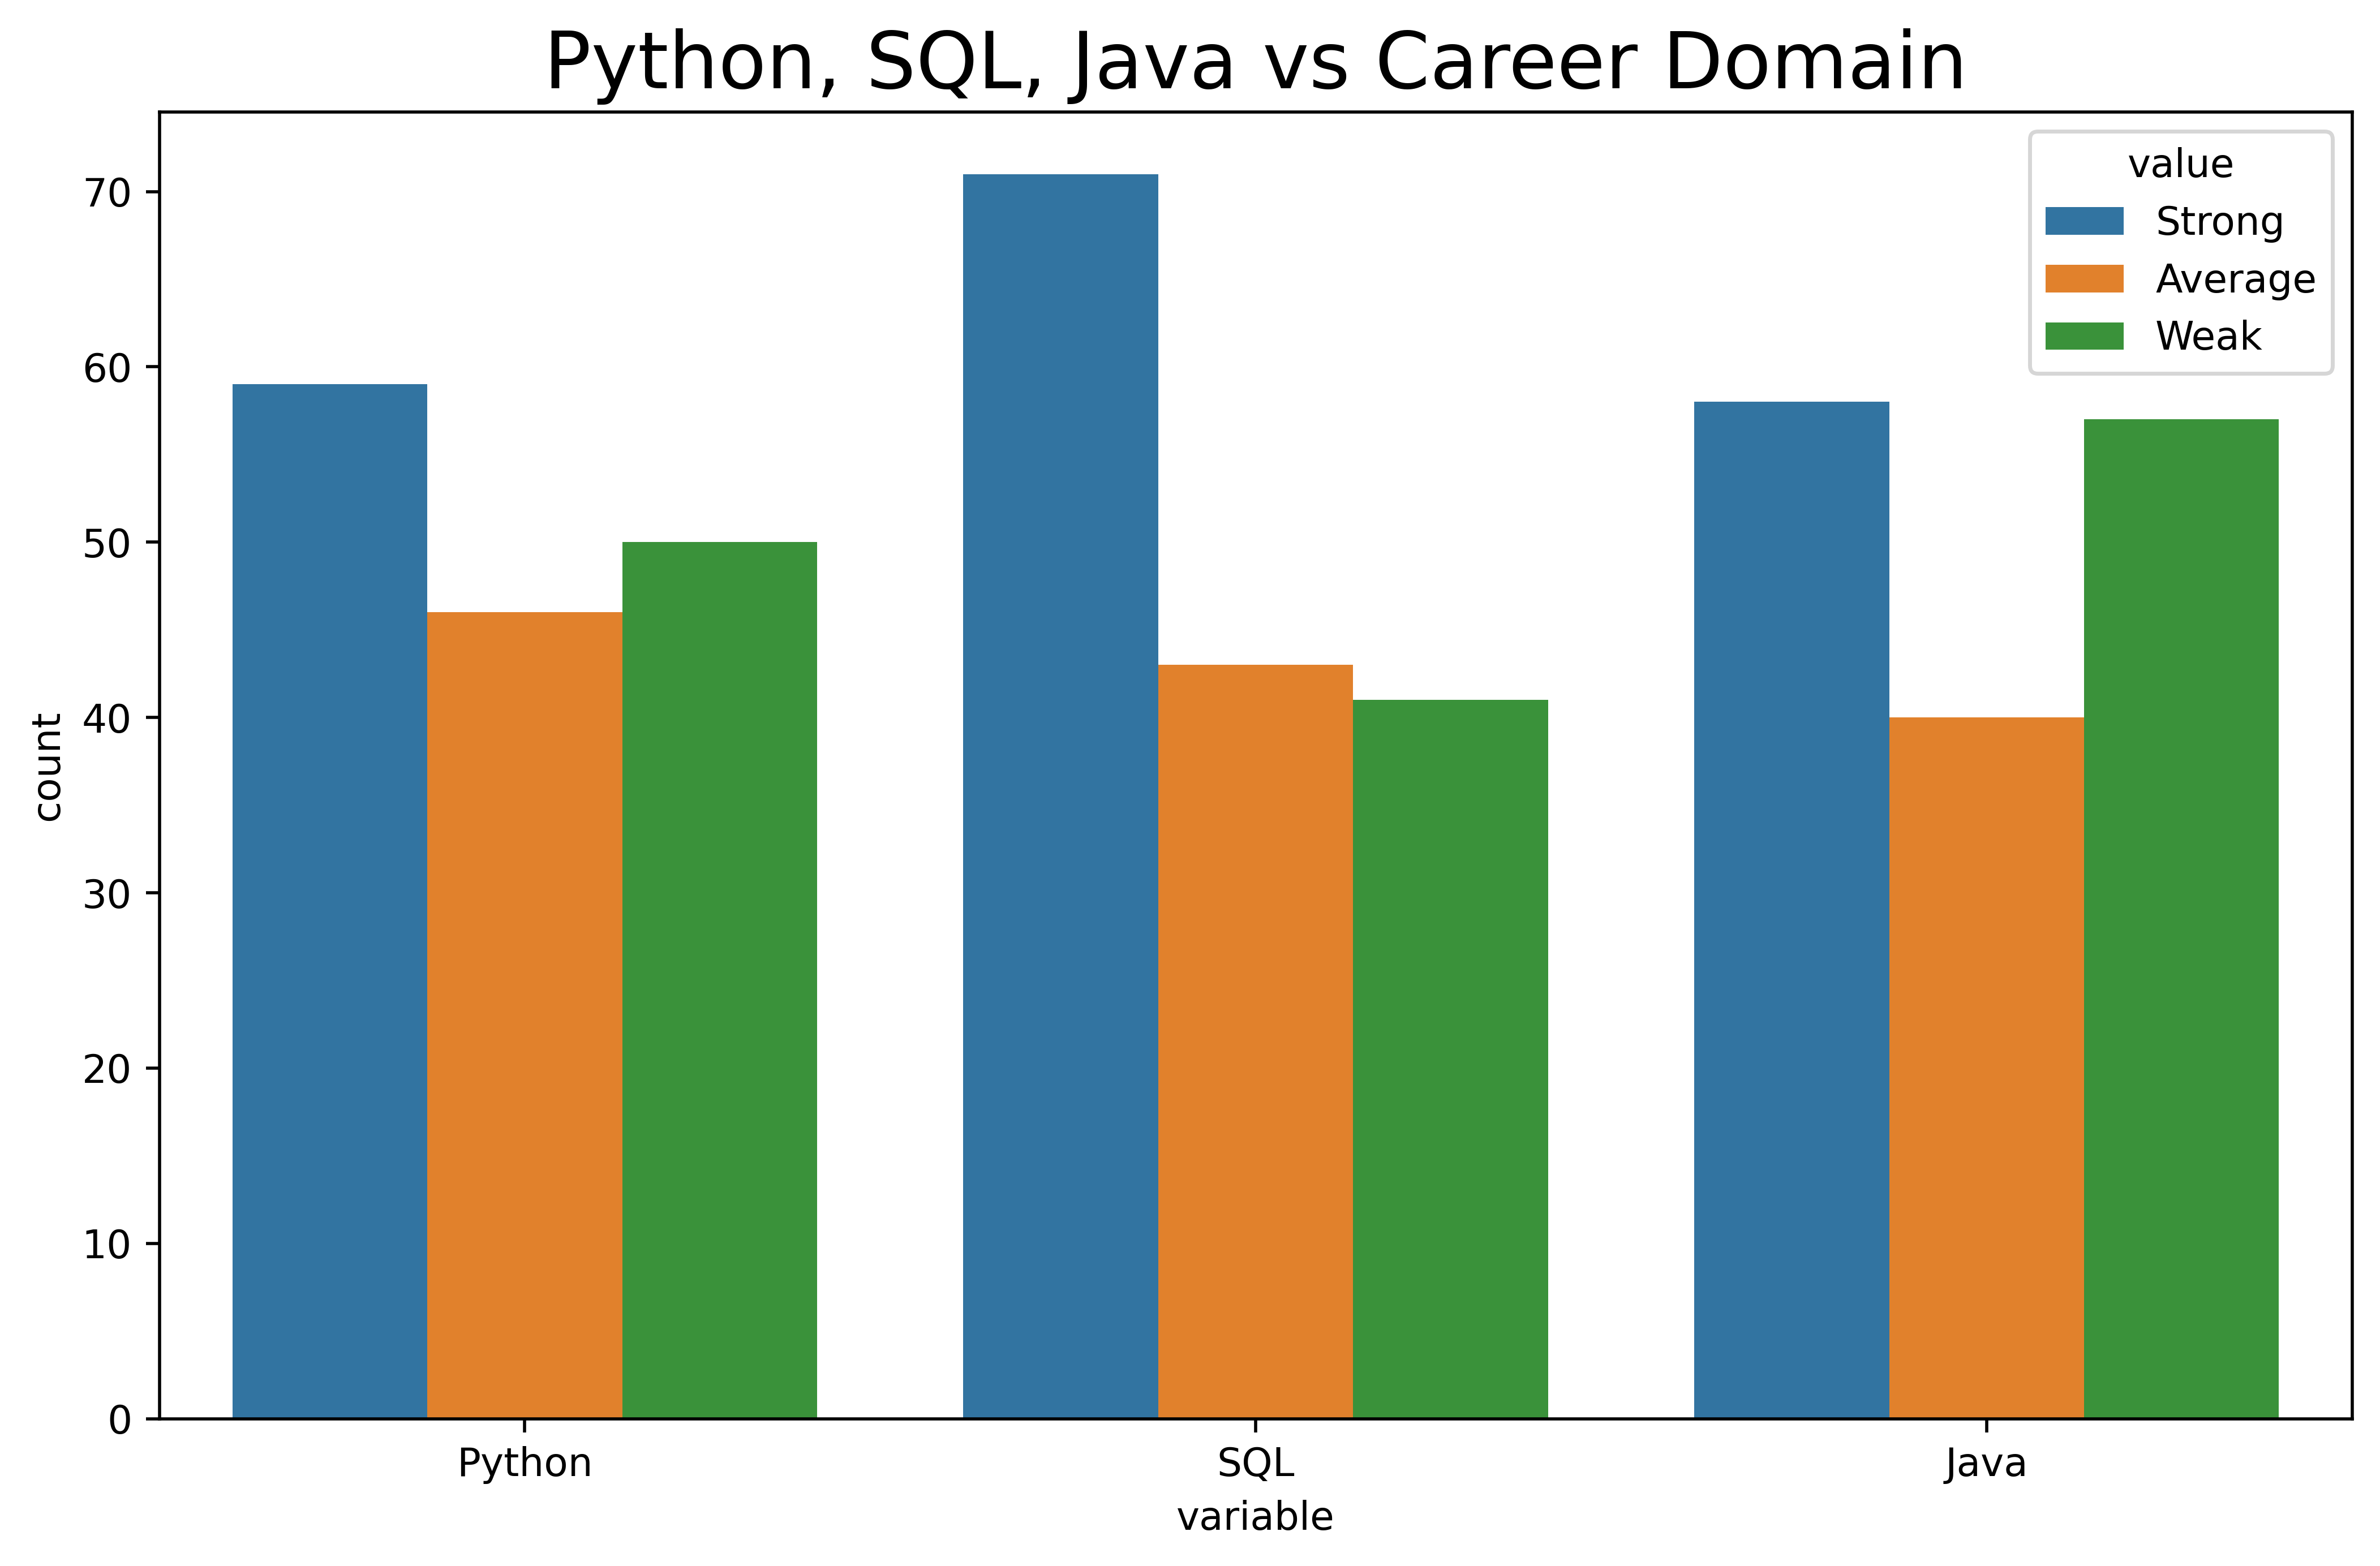

<Figure size 640x480 with 0 Axes>

In [116]:
# Skills Comparison of Python vs SQL vs Java
df_melt = df.melt(id_vars=["Interested Domain"], 
                  value_vars=["Python","SQL","Java"])

plt.figure(figsize=(10,6), dpi=500)
plt.title("Python, SQL, Java vs Career Domain", fontdict={'fontsize': 20})
sns.countplot(data=df_melt, x="variable", hue="value")
plt.show()
plt.savefig("images/skills-domain.png")